# Linear Combination of Atomic Orbitals and Hartree–Fock Theory
### University Physics II — Notebook 1: Theory

---

## Introduction: The Molecular Electronic Structure Problem

The central problem of molecular quantum mechanics is to determine the allowed electronic states of a molecule and their corresponding energies. In principle, this information is contained in the full Schrödinger equation for all nuclei and electrons interacting through Coulomb forces. In practice, however, this exact many-body problem is analytically intractable for all but the simplest systems.

The difficulty is not merely that molecules contain many particles, but that the electron-electron repulsion term couples the motion of all electrons together. As a result, the exact molecular wavefunction cannot generally be written as a simple product of independent one-electron states. Any practical theory of molecules must therefore introduce approximations that preserve the essential physics while reducing the problem to a form that can actually be solved.

The strategy followed in this notebook is the standard one used in electronic structure theory. First, the Born-Oppenheimer approximation is used to separate nuclear and electronic motion by treating the nuclei as fixed during the electronic calculation. This yields the electronic Hamiltonian, which governs electrons moving in the field of a fixed nuclear geometry. The remaining difficulty is then the many-electron character of the electronic wavefunction.

To approximate that wavefunction, Hartree-Fock theory replaces the exact many-electron problem by a variational problem over antisymmetric trial states. The antisymmetry requirement reflects the fermionic nature of electrons and leads naturally to the use of Slater determinants. The resulting one-electron orbitals are then expanded in a finite basis of atomic-like functions through the Linear Combination of Atomic Orbitals (LCAO) ansatz.

This sequence of approximations ultimately converts the continuous many-electron Schrödinger equation into a matrix eigenvalue problem that can be solved iteratively. The purpose of this notebook is therefore not merely to state the equations of LCAO and Hartree-Fock theory, but to explain why those equations take the form they do, what assumptions they rely on, and what physical meaning is retained at each stage.

## 1. The Electronic Problem

Solving the Schrödinger equation for a molecule is a formidable "many-body problem." A complete description requires accounting for the motion of every nucleus and every electron simultaneously, all while they exert Coulombic forces on one another.

### 1.1 The Born–Oppenheimer Approximation

The first step in making this solvable is the **Born–Oppenheimer (BO) approximation**. The physical basis for this is the massive disparity in inertia: because the proton-to-electron mass ratio is $m_p/m_e \approx 1836$, the nuclei are effectively "sluggish" compared to the near-instantaneous response of the electrons.



#### The Mathematical Decoupling
We assume the nuclei are stationary "point charges" from the perspective of the electrons. This allows us to **decouple** the total molecular wavefunction into two distinct parts:

$$\Psi_{\text{total}}(\mathbf{r}, \mathbf{R}) \approx \Psi_{\text{nuc}}(\mathbf{R})\,\Psi_{\text{el}}(\mathbf{r};\mathbf{R})$$

* **$\mathbf{R}$ (Nuclear Coordinates):** In the electronic wavefunction $\Psi_{\text{el}}$, $\mathbf{R}$ enters only **parametrically**. This means we treat the nuclear positions as fixed constants for a single calculation.
* **The Electronic Hamiltonian:** By freezing the nuclei, we remove their kinetic energy terms from the immediate problem. We are left with the **Electronic Schrödinger Equation**, where the electrons move within a static "external potential" generated by the fixed nuclear geometry $\{\mathbf{R}_A\}$.

This reduction is what allows us to calculate a molecule's energy at a specific bond length, then move the nuclei slightly and calculate it again to map out a **Potential Energy Surface (PES)**.

### 1.2 The Electronic Hamiltonian

The **Hamiltonian** ($\hat{H}$) is the total energy operator. In quantum mechanics, if we want to know the energy of a system, we "apply" this operator to the wavefunction. Under the Born–Oppenheimer approximation, we use the **Electronic Hamiltonian**, which describes the energy of $N$ electrons moving in the field of $M$ fixed nuclei.

To simplify the math, we use **atomic units** ($\hbar = m_e = e = 1$), where distances are measured in **Bohr** ($a_0$) and energy in **Hartrees** (Ha).

The equation breaks down into four distinct physical interactions:

$$\hat{H}_{\text{el}} = \underbrace{-\sum_{i=1}^{N}\frac{\nabla_i^2}{2}}_{\hat{T}_e} \underbrace{-\sum_{i=1}^{N}\sum_{A=1}^{M}\frac{Z_A}{r_{iA}}}_{\hat{V}_{eN}} + \underbrace{\sum_{i < j}\frac{1}{r_{ij}}}_{\hat{V}_{ee}} + \underbrace{\sum_{A < B}\frac{Z_A Z_B}{R_{AB}}}_{V_{NN}}$$

1.  **$\hat{T}_e$ (Electron Kinetic Energy):** The energy of motion for each electron $i$. The $\nabla^2$ (Laplacian) operator measures the "curvature" of the wavefunction.
2.  **$\hat{V}_{eN}$ (Nuclear Attraction):** The attractive Coulomb force between each electron $i$ and each nucleus $A$. This is what keeps the electrons bound to the molecule.
3.  **$\hat{V}_{ee}$ (Electron Repulsion):** This represents the repulsion between every pair of electrons. Because the position of one electron depends on the position of all others, this term makes the equation **inseparable**.
4.  **$V_{NN}$ (Nuclear Repulsion):** The repulsion between the fixed positive nuclei. Since the nuclei aren't moving (per our approximation), this is simply a **constant** value that shifts the total energy up but doesn't change the shape of the electron clouds.



While $\hat{T}_e$ and $\hat{V}_{eN}$ are "one-electron" operators (they only care about one electron at a time), $\hat{V}_{ee}$ is a "two-electron" operator. This term is the reason we cannot solve the Schrödinger equation exactly for anything larger than a hydrogen atom and must rely on the **Hartree–Fock method**.

### 1.3 The Hartree–Fock Solution: The Mean-Field Approximation
Because calculating the "instantaneous" repulsion between every moving pair of electrons is analytically impossible for any system larger than a single Hydrogen atom ($N > 1$), we use a strategy called the **Mean-Field Approximation**:

1.  We stop trying to track exactly where every electron is in relation to every other electron.
2.  Instead, we pretend that each individual electron is moving through an **average "cloud" of repulsion** created by all the other electrons.
3.  This "averaging" turns a complex, multi-body problem back into a collection of simpler, one-electron problems that a computer can iterate through.

**Summary:** Every advanced method in quantum chemistry is essentially a different strategy for handling the $\hat{V}_{ee}$ term more accurately. Hartree–Fock is the starting point, as it gives us the best possible "average" picture.

### 1.4 Why Atomic Orbitals Appear: The One-Electron Coulomb Problem

Before introducing LCAO, it is worth asking why atomic orbitals are used as basis functions at all. The answer comes from the one-electron Schrödinger equation in a Coulomb potential, which is one of the few nontrivial quantum systems that can be solved analytically.

For a nucleus of charge \(+Z\) fixed at the origin, the one-electron Hamiltonian in atomic units is

$$
\hat{H} = -\frac{1}{2}\nabla^2 - \frac{Z}{r}.
$$

The stationary states satisfy the time-independent Schrödinger equation

$$
\hat{H}\psi(\mathbf{r}) = E\psi(\mathbf{r}).
$$

Because the potential depends only on the distance \(r\), the problem is spherically symmetric. This allows separation of variables in spherical coordinates, so the wavefunction can be written as

$$
\psi_{n\ell m}(r,\theta,\phi) = R_{n\ell}(r)Y_\ell^m(\theta,\phi),
$$

where $Y_\ell^m(\theta,\phi)$ are the spherical harmonics and $R_{n\ell}(r)$ is the radial wavefunction. These solutions are energy eigenstates, with discrete energies

$$
E_n = -\frac{Z^2}{2n^2}.
$$

These eigenstates are the familiar atomic orbitals. Their importance here is not merely historical. They provide a mathematically natural and physically motivated set of one-electron functions. Near a given nucleus, the molecular potential still resembles an atomic Coulomb potential, so the exact molecular orbitals are expected to retain local atomic character. This is the main reason atomic orbitals form a sensible starting basis for molecular calculations.

Hydrogen is exactly solvable because it contains only one electron. In many-electron atoms and molecules, the electron-electron repulsion term couples the coordinates of different electrons together, destroying the separability of the problem. Exact analytic eigenstates are then no longer available, and one must instead construct approximate solutions from physically motivated basis functions. The LCAO method is one such construction.

## 2. The LCAO Basis: Atomic Orbitals as Expansion Functions

To solve for the electron's behavior in a molecule, we need a mathematical "starting point." Since we know how electrons behave around individual atoms, we use those atomic shapes as our building blocks.

### 2.1 Why Atoms Provide a Natural Basis

In physics, an **eigenfunction** is a specific state where a system has a definite energy. For a single atom, the eigenfunctions are the classic atomic orbitals ($1s, 2p,$ etc.).

The LCAO method assumes that even when atoms bond to form a molecule, the resulting **Molecular Orbitals (MOs)** will still look like a mixture of those original atomic shapes. We treat these atomic orbitals as a **Basis Set**—a collection of functions that can be added together to span the space of the molecule.

#### The LCAO Equation
We define the $i$-th molecular orbital ($\phi_i$) as a weighted sum of $K$ atomic orbitals ($\tilde{\chi}_\mu$):

$$\boxed{\phi_i(\mathbf{r}) = \sum_{\mu=1}^{K} C_{\mu i}\,\tilde{\chi}_\mu(\mathbf{r})}$$

* **$\tilde{\chi}_\mu$ (The Basis Functions):** These are the "fixed" shapes (like $s, p, d$ orbitals) centered on the various nuclei.
* **$C_{\mu i}$ (The Expansion Coefficients):** These are the **unknowns**. They act as "knobs" that we turn to adjust how much of each atomic orbital is used to create the final molecular orbital.
* **The Matrix $\mathbf{C}$:** In computational practice, we solve for a whole matrix of these coefficients.


### 2.2 The Convergence Limits
It is important to note that the accuracy of an LCAO calculation is mathematically capped by two independent factors:

1.  Using a single Slater Determinant (Hartree–Fock) ignores some complex electron-electron correlations.
2. If your "alphabet" of atomic orbitals is too small (e.g., only using $1s$ orbitals for a complex molecule), you can never perfectly describe the true molecular orbital, no matter how much you optimize the coefficients. This is known as the **Basis Set Limit**.

**Note:** The summation $\mu$ can include orbitals from any atom in the molecule. This generality allows us to describe "delocalized" electrons—electrons that are shared across the entire molecular framework rather than being stuck on one atom.

The only exactly solvable atom is hydrogen ($Z=1$, one electron). Its energy eigenstates in atomic units are:

$$E_n = -\frac{Z^2}{2n^2}, \qquad \psi_{n\ell m}(r,\theta,\varphi) = R_{n\ell}(r)\,Y_\ell^m(\theta,\varphi)$$

where $Y_\ell^m$ are spherical harmonics encoding angular shape, and $R_{n\ell}(r)$ is the radial part:

$$R_{n\ell}(r) = \sqrt{\left(\frac{2Z}{n}\right)^3 \frac{(n-\ell-1)!}{2n[(n+\ell)!]^3}}\, e^{-Zr/n} \left(\frac{2Zr}{n}\right)^\ell L_{n-\ell-1}^{2\ell+1}\!\left(\frac{2Zr}{n}\right)$$

where $L_{n-\ell-1}^{2\ell+1}$ are associated Laguerre polynomials. For the 1s orbital ($n=1, \ell=0, m=0$):

$$\psi_{1s}(r) = \frac{Z^{3/2}}{\sqrt{\pi}}\,e^{-Zr}$$

This exact form motivates **Slater-type orbitals (STOs)**: basis functions of the form $r^{n-1}e^{-\zeta r}Y_\ell^m(\theta,\varphi)$, where $\zeta$ is an adjustable exponent. STOs reproduce the correct exponential decay and the nuclear cusp ($|\nabla\psi| \to -Z\psi$ as $r\to 0$), but multi-center integrals between STOs on different atoms are analytically intractable.

### 2.3 Gaussian-Type Orbitals (GTOs)

In an ideal theoretical world, we would use **Slater-Type Orbitals (STOs)** because they mimic the true exponential decay of electron density ($e^{-r}$). However, calculating the interactions between four different STOs centered on different atoms is so mathematically complex that it creates a computational bottleneck.

To solve this, we use **Gaussian-Type Orbitals (GTOs)**, which replace the "Slater" exponential with a Gaussian function ($e^{-r^2}$):

$$g(\mathbf{r}; \alpha, \ell) = N\,x^a y^b z^c\,e^{-\alpha r^2}, \qquad \text{where } a+b+c = \ell$$

* **$N$ (Normalization Constant):** Ensures that the probability of finding the electron somewhere in space is exactly 1.
* **The Polynomial ($x^a y^b z^c$):** This defines the **angular momentum** ($\ell$). For example, if the exponents sum to 0 ($x^0 y^0 z^0$), it's an $s$-orbital; if they sum to 1 (e.g., $x^1 y^0 z^0$), it’s a $p$-orbital.
* **$\alpha$ (The Exponent):** Controls the "width" of the orbital. A large $\alpha$ makes a tight, compact orbital near the nucleus; a small $\alpha$ makes a diffuse, spread-out orbital.
* **$e^{-\alpha r^2}$ (The Gaussian Radial Part):** The core mathematical shift that simplifies the integration.


However, GTOs are physically "imperfect" in two key ways:
1.  **The Cusp Problem:** At the nucleus ($r=0$), real orbitals have a sharp "point" (a derivative discontinuity). GTOs are smooth and flat at the center, which poorly describes the behavior of electrons very close to the nucleus.
2.  **The Tail Problem:** Because $e^{-r^2}$ decays much faster than $e^{-r}$, GTOs "die off" too quickly at large distances, underrepresenting the electron density in the outer regions of the molecule.


Why do we use them if they have these defects? The answer is the **Gaussian Product Theorem**.

Mathematically, the product of two Gaussians centered at two different points ($\mathbf{A}$ and $\mathbf{B}$) is exactly equal to a **single new Gaussian** centered at a point $\mathbf{P}$ located on the line segment connecting them:

$$e^{-\alpha|\mathbf{r}-\mathbf{A}|^2}\,e^{-\beta|\mathbf{r}-\mathbf{B}|^2} = e^{-\gamma|\mathbf{A}-\mathbf{B}|^2}\,e^{-(\alpha+\beta)|\mathbf{r}-\mathbf{P}|^2}$$

This is a computational "cheat code." It allows us to turn incredibly difficult **multi-center integrals** (where we have to calculate interactions between four different locations in space) into simple **one-center integrals**. This makes evaluating the complex two-electron repulsion terms analytically feasible for a computer.

We fix the physical inaccuracies of GTOs by using a "Contracted Basis Set"—summing several GTOs together to "fit" the shape of a real Slater orbital.

### 2.4 Contracted Basis Sets

As we noted, a single Gaussian-Type Orbital (GTO) is physically inaccurate near the nucleus and at long distances. To fix this without losing the computational speed of Gaussians, we use **contraction**. Instead of using one "primitive" Gaussian to represent an atomic orbital, we glue several together into a single, fixed package.

#### The Contraction Equation
Each basis function $\tilde{\chi}_\mu$ is defined as a fixed sum of $L$ "primitive" Gaussians ($g_k$):

$$\tilde{\chi}_\mu(\mathbf{r}) = \sum_{k=1}^{L} d_{\mu k}\,g_k(\mathbf{r};\alpha_{\mu k})$$

* **$g_k$ (Primitive Gaussians):** The individual "raw" Gaussian functions ($e^{-r^2}$).
* **$\alpha_{\mu k}$ (Exponents):** These determine how wide or narrow each primitive is.
* **$d_{\mu k}$ (Contraction Coefficients):** These are the "weights" that determine how much of each primitive is used to create the final shape.
* **$L$ (Contraction Degree):** The number of primitives used. In an "STO-3G" basis, $L=3$ (3 primitives per orbital).

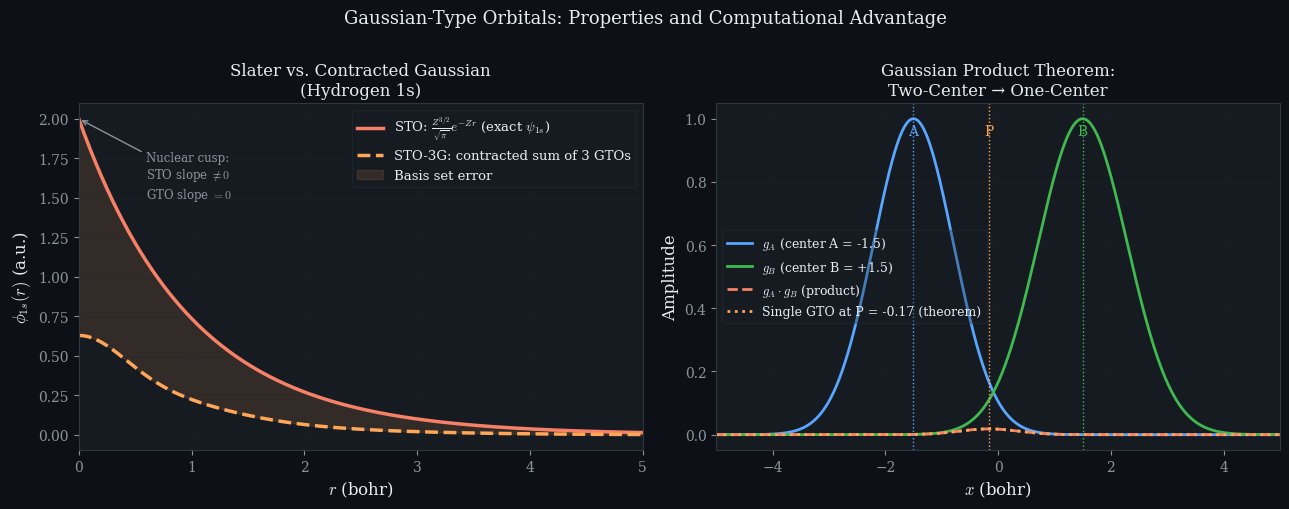

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.linalg import eigh

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'axes.titlecolor':  '#e6edf3',
    'font.family':      'serif',
    'mathtext.fontset': 'cm',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})


# Visualize: STO vs. contracted GTO (STO-3G) for hydrogen 1s
# STO-3G exponents and contraction coefficients for H 1s

r = np.linspace(0, 6, 600)

# Normalized hydrogen 1s STO (zeta = 1)
zeta = 1.0
sto = 2 * zeta**(3/2) * np.exp(-zeta * r)   # psi_1s in a.u.

# STO-3G parameters for H 1s (standard values)
alphas = np.array([3.4252509, 0.6239137, 0.1688554])
coeffs = np.array([0.1543290, 0.5353281, 0.4446345])
norms  = (2.0 * alphas / np.pi)**0.75          # normalization of each primitive

# Individual primitives and their contracted sum
primitives = [coeffs[k] * norms[k] * np.exp(-alphas[k]*r**2) for k in range(3)]
gto_sum    = sum(primitives)
prim_cols  = ['#58a6ff', '#3fb950', '#d2a8ff']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: STO vs. contracted GTO ---
ax = axes[0]
ax.plot(r, sto,      color='#f78166', lw=2.5, label=r'STO: $\frac{Z^{3/2}}{\sqrt{\pi}}e^{-Zr}$ (exact $\psi_{1s}$)')
ax.plot(r, gto_sum,  color='#ffa657', lw=2.5, ls='--', label='STO-3G: contracted sum of 3 GTOs')
ax.fill_between(r, sto, gto_sum, alpha=0.12, color='#ffa657', label='Basis set error')
ax.set_xlabel('$r$ (bohr)', fontsize=12)
ax.set_ylabel('$\\phi_{1s}(r)$ (a.u.)', fontsize=12)
ax.set_title('Slater vs. Contracted Gaussian\n(Hydrogen 1s)', fontsize=12)
ax.legend(fontsize=9.5, framealpha=0.3)
ax.set_xlim(0, 5); ax.grid(alpha=0.2)

# Note the nuclear cusp: STO has nonzero slope at origin, GTO does not
ax.annotate('Nuclear cusp:\nSTO slope $\\neq 0$\nGTO slope $= 0$',
            xy=(0, sto[0]), xytext=(0.6, 1.5),
            fontsize=8.5, color='#8b949e',
            arrowprops=dict(arrowstyle='->', color='#8b949e', lw=1))

# --- Right: Gaussian product theorem illustration ---
ax2 = axes[1]
alpha_A, alpha_B = 1.0, 0.8
A_pos, B_pos = -1.5, 1.5
r2 = np.linspace(-5, 5, 600)
gA = np.exp(-alpha_A * (r2 - A_pos)**2)
gB = np.exp(-alpha_B * (r2 - B_pos)**2)
gamma = alpha_A * alpha_B / (alpha_A + alpha_B)
P_pos = (alpha_A * A_pos + alpha_B * B_pos) / (alpha_A + alpha_B)
K_AB  = np.exp(-gamma * (A_pos - B_pos)**2)
gP    = K_AB * np.exp(-(alpha_A + alpha_B) * (r2 - P_pos)**2)
product_AB = gA * gB

ax2.plot(r2, gA,         color='#58a6ff', lw=2, label=r'$g_A$ (center A = -1.5)')
ax2.plot(r2, gB,         color='#3fb950', lw=2, label=r'$g_B$ (center B = +1.5)')
ax2.plot(r2, product_AB, color='#f78166', lw=2, ls='--', label=r'$g_A \cdot g_B$ (product)')
ax2.plot(r2, gP,         color='#ffa657', lw=2, ls=':',  label=f'Single GTO at P = {P_pos:.2f} (theorem)')
ax2.axvline(A_pos, color='#58a6ff', lw=1, ls=':')
ax2.axvline(B_pos, color='#3fb950', lw=1, ls=':')
ax2.axvline(P_pos, color='#ffa657', lw=1, ls=':')
ax2.text(A_pos, 0.95, 'A', color='#58a6ff', ha='center', fontsize=10)
ax2.text(B_pos, 0.95, 'B', color='#3fb950', ha='center', fontsize=10)
ax2.text(P_pos, 0.95, 'P', color='#ffa657', ha='center', fontsize=10)
ax2.set_xlabel('$x$ (bohr)', fontsize=12)
ax2.set_ylabel('Amplitude', fontsize=12)
ax2.set_title('Gaussian Product Theorem:\nTwo-Center → One-Center', fontsize=12)
ax2.legend(fontsize=9, framealpha=0.3)
ax2.set_xlim(-5, 5); ax2.grid(alpha=0.2)

plt.suptitle('Gaussian-Type Orbitals: Properties and Computational Advantage', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 The Overlap Matrix: Measuring Orbital Interaction

In a standard Cartesian coordinate system, the axes are **orthogonal**, meaning they are perfectly independent. However, in a molecule, atomic orbitals centered on different atoms are **non-orthogonal**. They share the same physical space, and the overlap matrix $\mathbf{S}$ is how we track that shared "real estate."

#### The Mathematical Definition
The **Overlap Matrix ($\mathbf{S}$)** quantifies the spatial coincidence between two basis functions ($\tilde{\chi}_\mu$ and $\tilde{\chi}_\nu$):

$$S_{\mu\nu} = \int_{\mathbb{R}^3} \tilde{\chi}_\mu^*(\mathbf{r})\,\tilde{\chi}_\nu(\mathbf{r})\,d\mathbf{r} = \braket{\tilde{\chi}_\mu}{\tilde{\chi}_\nu}$$

* **$S_{\mu\nu}$ (Matrix Element):** The numerical "score" representing the extent of overlap between orbital $\mu$ and orbital $\nu$.
* **$\tilde{\chi}_\mu^*(\mathbf{r})$ (Complex Conjugate):** The mathematical description of the first orbital.
* **$\tilde{\chi}_\nu(\mathbf{r})$ (Basis Function):** The mathematical description of the second orbital.
* **$d\mathbf{r}$ (Volume Element):** Indicates that we are integrating (summing) the interaction across all 3D space.
* **$\braket{\tilde{\chi}_\mu}{\tilde{\chi}_\nu}$ (Bra-Ket Notation):** A shorthand way to write the integral above.



In computational chemistry, non-orthogonality is the physical driver of chemical bonding. The way these functions overlap determines the stability of the molecule:

1.  **Constructive Interference ($S_{\mu\nu} > 0$):** The wavefunctions add together, increasing electron density between nuclei. This acts as "quantum glue," lowering the energy to form a **bonding orbital**.
2.  **Destructive Interference:** When orbitals combine with opposing signs, they cancel out, creating a **node** (zero density) between nuclei. This raises the system energy, forming an **antibonding orbital**.




#### An Analytical Example: The Hydrogen Molecule
For two Hydrogen $1s$ orbitals (Slater-Type) separated by a distance $R$, the overlap can be calculated exactly:

$$S_{\mu\nu}(R) = e^{-R}\left(1 + R + \frac{R^2}{3}\right)$$

* **$e^{-R}$ (Exponential Decay):** This term ensures that as the distance $R$ increases, the overlap vanishes rapidly.
* **$(1 + R + \frac{R^2}{3})$ (Polynomial Correction):** This accounts for the specific spherical geometry of the $1s$ orbitals as they merge.
* **$R$ (Internuclear Distance):** The separation between the two nuclei in atomic units (Bohr).

This equation demonstrates why atoms must be physically close to bond; if $R$ is large, the "glue" ($S_{\mu\nu}$) disappears.

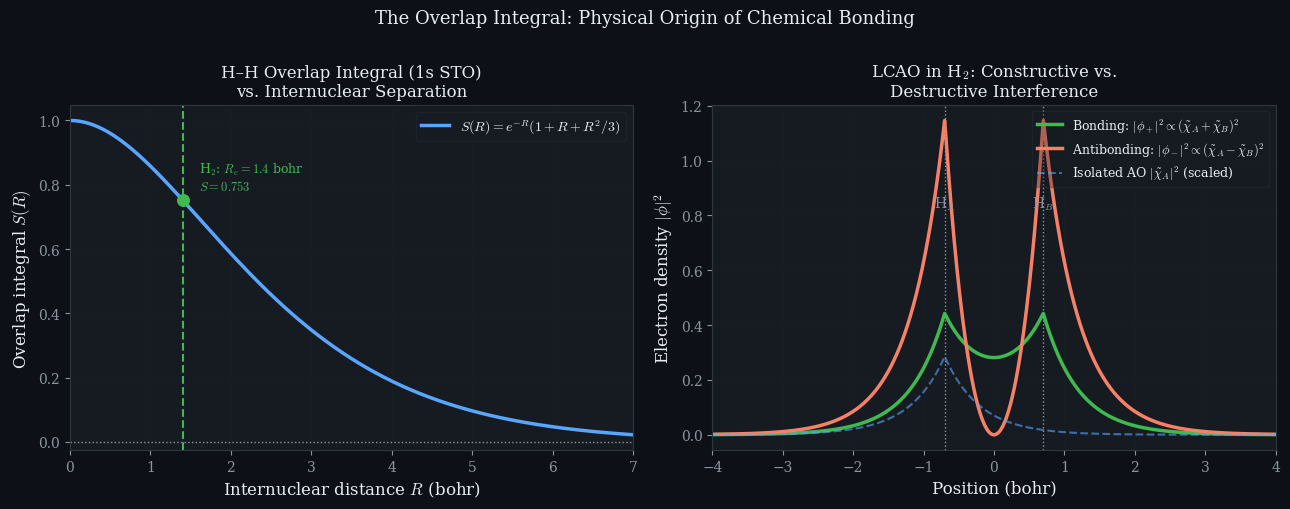

In [ ]:
# Overlap integral and LCAO bonding/antibonding for H2
# Exact STO-1s result: S(R) = exp(-R)(1 + R + R^2/3)
R = np.linspace(0, 7, 500)
S_sto = np.exp(-R) * (1 + R + R**2/3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: S(R) ---
ax = axes[0]
ax.plot(R, S_sto, color='#58a6ff', lw=2.5, label=r'$S(R) = e^{-R}(1 + R + R^2/3)$')
R_eq = 1.4    # H2 equilibrium bond length in bohr
S_eq = np.exp(-R_eq) * (1 + R_eq + R_eq**2/3)
ax.axvline(R_eq, color='#3fb950', ls='--', lw=1.5)
ax.scatter([R_eq], [S_eq], color='#3fb950', zorder=5, s=70)
ax.text(R_eq + 0.2, S_eq + 0.03,
        f'H$_2$: $R_e = 1.4$ bohr\n$S = {S_eq:.3f}$',
        color='#3fb950', fontsize=9)
ax.axhline(0, color='#8b949e', ls=':', lw=1)
ax.set_xlabel('Internuclear distance $R$ (bohr)', fontsize=12)
ax.set_ylabel('Overlap integral $S(R)$', fontsize=12)
ax.set_title('H–H Overlap Integral (1s STO)\nvs. Internuclear Separation', fontsize=12)
ax.legend(fontsize=10, framealpha=0.3)
ax.set_xlim(0, 7); ax.grid(alpha=0.2)

# --- Right: bonding and antibonding charge densities ---
ax2 = axes[1]
x   = np.linspace(-4, 4, 600)
R0  = R_eq / 2.0
phi_A = np.exp(-np.abs(x + R0))   # 1s STO on nucleus A
phi_B = np.exp(-np.abs(x - R0))   # 1s STO on nucleus B

# Normalized linear combinations
N_plus  = 1.0 / np.sqrt(2*(1 + S_eq))
N_minus = 1.0 / np.sqrt(2*(1 - S_eq))
bonding     = N_plus  * (phi_A + phi_B)
antibonding = N_minus * (phi_A - phi_B)

ax2.plot(x, bonding**2,       color='#3fb950', lw=2.5,
         label=r'Bonding: $|\phi_+|^2 \propto (\tilde{\chi}_A + \tilde{\chi}_B)^2$')
ax2.plot(x, antibonding**2,   color='#f78166', lw=2.5,
         label=r'Antibonding: $|\phi_-|^2 \propto (\tilde{\chi}_A - \tilde{\chi}_B)^2$')
ax2.plot(x, phi_A**2 * N_plus**2, color='#58a6ff', lw=1.5, ls='--',
         alpha=0.6, label=r'Isolated AO $|\tilde{\chi}_A|^2$ (scaled)')
ax2.axvline(-R0, color='#8b949e', ls=':', lw=1)
ax2.axvline(+R0, color='#8b949e', ls=':', lw=1)
ax2.text(-R0, 0.83, 'H$_A$', ha='center', color='#8b949e', fontsize=10)
ax2.text(+R0, 0.83, 'H$_B$', ha='center', color='#8b949e', fontsize=10)
ax2.set_xlabel('Position (bohr)', fontsize=12)
ax2.set_ylabel('Electron density $|\\phi|^2$', fontsize=12)
ax2.set_title('LCAO in H$_2$: Constructive vs.\nDestructive Interference', fontsize=12)
ax2.legend(fontsize=9, framealpha=0.3)
ax2.set_xlim(-4, 4); ax2.grid(alpha=0.2)

plt.suptitle('The Overlap Integral: Physical Origin of Chemical Bonding', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. The Many-Electron Wavefunction: The Slater Determinant

So far, we have focused on a single molecular orbital. However, a molecule is a multi-electron system. To describe the whole molecule, we need a mathematical structure that holds $N$ electrons simultaneously while obeying the laws of quantum physics.

### 3.1 The Antisymmetry Principle: The Fermion Rule

Electrons belong to a class of particles called **fermions**. A fundamental law of nature, the **Antisymmetry Postulate**, states that if you swap the positions and spins of any two identical fermions, the sign of the total wavefunction must flip (become negative).

$$\Psi(\ldots, \mathbf{x}_i, \ldots, \mathbf{x}_j, \ldots) = -\Psi(\ldots, \mathbf{x}_j, \ldots, \mathbf{x}_i, \ldots)$$

* **$\Psi$ (The Total Wavefunction):** The mathematical description of the entire $N$-electron system.
* **$\mathbf{x}_i$ and $\mathbf{x}_j$ (Combined Coordinates):** These represent the full state of electron $i$ and electron $j$.
* **The Minus Sign ($- \Psi$):** This represents the "antisymmetry." It is the mathematical requirement that leads to the **Pauli Exclusion Principle** (no two electrons can occupy the exact same state).

To satisfy this, we don't just look at where an electron is in space ($\mathbf{r}$); we also look at its "spin" ($\omega$). We combine these into a **Spin Orbital**:

$$\chi_i(\mathbf{x}) = \phi_i(\mathbf{r})\,\sigma(\omega)$$

* **$\chi_i(\mathbf{x})$ (Spin Orbital):** The complete state of the electron.
* **$\phi_i(\mathbf{r})$ (Spatial Orbital):** The LCAO orbital we built in Section 2 (the "cloud" shape).
* **$\sigma(\omega)$ (Spin Function):** The spin state, usually designated as $\alpha$ (spin up) or $\beta$ (spin down).
* **$\mathbf{x}$:** The combined variable representing both position ($\mathbf{r}$) and spin ($\omega$).



#### The Failure of the Hartree Product
A simple way to build a multi-electron system would be to just multiply the orbitals together: $\chi_1(\mathbf{x}_1)\chi_2(\mathbf{x}_2)\cdots$. This is called a **Hartree Product**.

However, if you swap electron 1 and electron 2 in a Hartree product, the equation doesn't flip its sign—it just changes into a different product entirely. This fails the physical requirement of antisymmetry. To fix this, we need a more sophisticated mathematical "container": the **Slater Determinant**.

### 3.2 The Slater Determinant

To fix the failure of the Hartree product, we use the **Slater Determinant**. This mathematical structure ensures that the wavefunction is antisymmetric by construction—meaning the physics is "built-in" to the math.

#### The Determinant Equation
The many-electron state $\ket{\Phi}$ is represented as a matrix where rows are electrons and columns are the spin orbitals they occupy:

$$\ket{\Phi} = \frac{1}{\sqrt{N!}}
\begin{vmatrix}
\chi_1(\mathbf{x}_1) & \chi_2(\mathbf{x}_1) & \cdots & \chi_N(\mathbf{x}_1) \\
\chi_1(\mathbf{x}_2) & \chi_2(\mathbf{x}_2) & \cdots & \chi_N(\mathbf{x}_2) \\
\vdots & \vdots & \ddots & \vdots \\
\chi_1(\mathbf{x}_N) & \chi_2(\mathbf{x}_N) & \cdots & \chi_N(\mathbf{x}_N)
\end{vmatrix}$$

* **$\frac{1}{\sqrt{N!}}$ (Normalization Factor):** This ensures the total probability of finding the $N$ electrons in space is exactly 1.
* **$\chi_j(\mathbf{x}_i)$ (Matrix Element):** This represents electron $i$ occupying spin orbital $j$.
* **The Determinant Bars ($|\dots|$):** In linear algebra, swapping two rows of a determinant flips the sign of the result. Since rows represent electrons, swapping two electrons automatically makes the wavefunction negative, satisfying the **Antisymmetry Principle**.



By using this specific mathematical form, we gain two critical insights:

1.  **The Pauli Exclusion Principle:** In linear algebra, if two columns of a matrix are identical, the determinant becomes zero. Physically, this means if you try to put two electrons in the same spin orbital ($\chi_i = \chi_j$), the wavefunction vanishes. It is mathematically impossible for them to be in the same state.
2.  **Electron Indistinguishability:** Notice that every electron ($\mathbf{x}_1, \mathbf{x}_2, \dots$) appears in every orbital column. In this model, we do not say "Electron 1 is in Orbital A." Instead, every electron is distributed across all occupied orbitals simultaneously. This perfectly mirrors the quantum reality that electrons have no "labels."

Ergo, the Slater Determinant is our "trial wavefunction." It is the most mathematically simple way to describe a group of electrons while respecting their fundamental nature as fermions.

### 3.3 The HF Ansatz and Its Limitations

Hartree–Fock theory posits that the true many-electron ground state is *well approximated* by a single Slater determinant built from optimized spin orbitals. This is the **independent-particle approximation**: once the mean field is determined, each electron behaves as if it were in an independent one-electron problem. The quality of this approximation depends on the system.

The fundamental limitation is that a single determinant cannot capture **dynamic electron correlation**—the tendency of electrons to avoid each other *instantaneously*, beyond what the average mean-field accounts for. The energy difference between the exact ground state and the HF result is the correlation energy $E_c = E_0 - E_{\text{HF}} < 0$. For most molecules near equilibrium geometry, $|E_c|$ is small compared to $E_{\text{HF}}$, but it is comparable to bond energies ($\sim$ 1–3 eV). Any quantitative thermochemistry therefore requires going beyond HF.

---
## 4. The Variational Principle

### 4.1 Statement and Proof

We have a trial wavefunction (the Slater determinant) parameterized by the coefficients $C_{\mu i}$. We need a criterion for choosing these coefficients. The **variational principle** provides one:

> For any normalized trial wavefunction $\ket{\tilde{\Psi}}$, the variational energy is an upper bound to the exact ground-state energy $E_0$:
> $$E_{\text{var}} = \mel{\tilde{\Psi}}{\hat{H}}{\tilde{\Psi}} \geq E_0$$

where

* **$E_{\text{var}}$ (Variational Energy):** The energy value resulting from our specific trial wavefunction.
* **$\ket{\tilde{\Psi}}$ (Trial Wavefunction):** Our "guess" at the state of the system (in this notebook, the Slater determinant).
* **$\hat{H}$ (Hamiltonian Operator):** The operator representing the total energy of the system.
* **$\mel{\tilde{\Psi}}{\hat{H}}{\tilde{\Psi}}$ (Expectation Value):** The average energy of the system when it is in state $\tilde{\Psi}$.
* **$E_0$ (Exact Ground-State Energy):** The true, physical minimum energy possible for the system.


**Proof.** Let $\{\ket{\Psi_n}\}$ be the complete set of exact eigenstates, $\hat{H}\ket{\Psi_n} = E_n\ket{\Psi_n}$, ordered $E_0 \leq E_1 \leq E_2 \leq \cdots$ Expand the trial state in this basis:

$$\ket{\tilde{\Psi}} = \sum_n c_n\ket{\Psi_n}, \qquad \sum_n |c_n|^2 = 1 \;(\text{normalization})$$

* **$\ket{\Psi_n}$ (Exact Eigenstates):** The "true" solutions to the Schrödinger equation, where $\hat{H}\ket{\Psi_n} = E_n\ket{\Psi_n}$.
* **$c_n$ (Expansion Coefficients):** Values indicating how much of each true state $n$ is "mixed" into our trial guess.
* **$\sum_n |c_n|^2 = 1$ (Normalization):** A requirement that ensures the total probability of all possible states sums to 100%.

Substituting this into the energy equation:

$$E_{\text{var}} = \sum_n |c_n|^2 E_n \geq E_0\sum_n|c_n|^2 = E_0$$

* **$E_n$ (Energy Eigenvalues):** The energy levels of the true states, ordered such that $E_0$ is the lowest.
* **$E_0\sum_n|c_n|^2$:** Since $E_0$ is the minimum, replacing every $E_n$ in the sum with $E_0$ creates a value that is necessarily smaller than or equal to the original sum.

Equality holds if and only if $\ket{\tilde{\Psi}} = \ket{\Psi_0}$ exactly—the trial function is already the exact ground state.

### 4.2 Energy Minimization as the Criterion

The variational principle converts the eigenvalue problem into an **optimization problem**: among all Slater determinants in the chosen AO basis, find the one that minimizes $E_{\text{var}}$. The minimizer is the Hartree–Fock ground state. Since $E_{\text{var}} \geq E_0$ always, every computational improvement—larger basis, better trial function, post-HF correlation—must lower the energy. A lower variational energy is unambiguously better.

/tmp/ipykernel_18563/3796593180.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


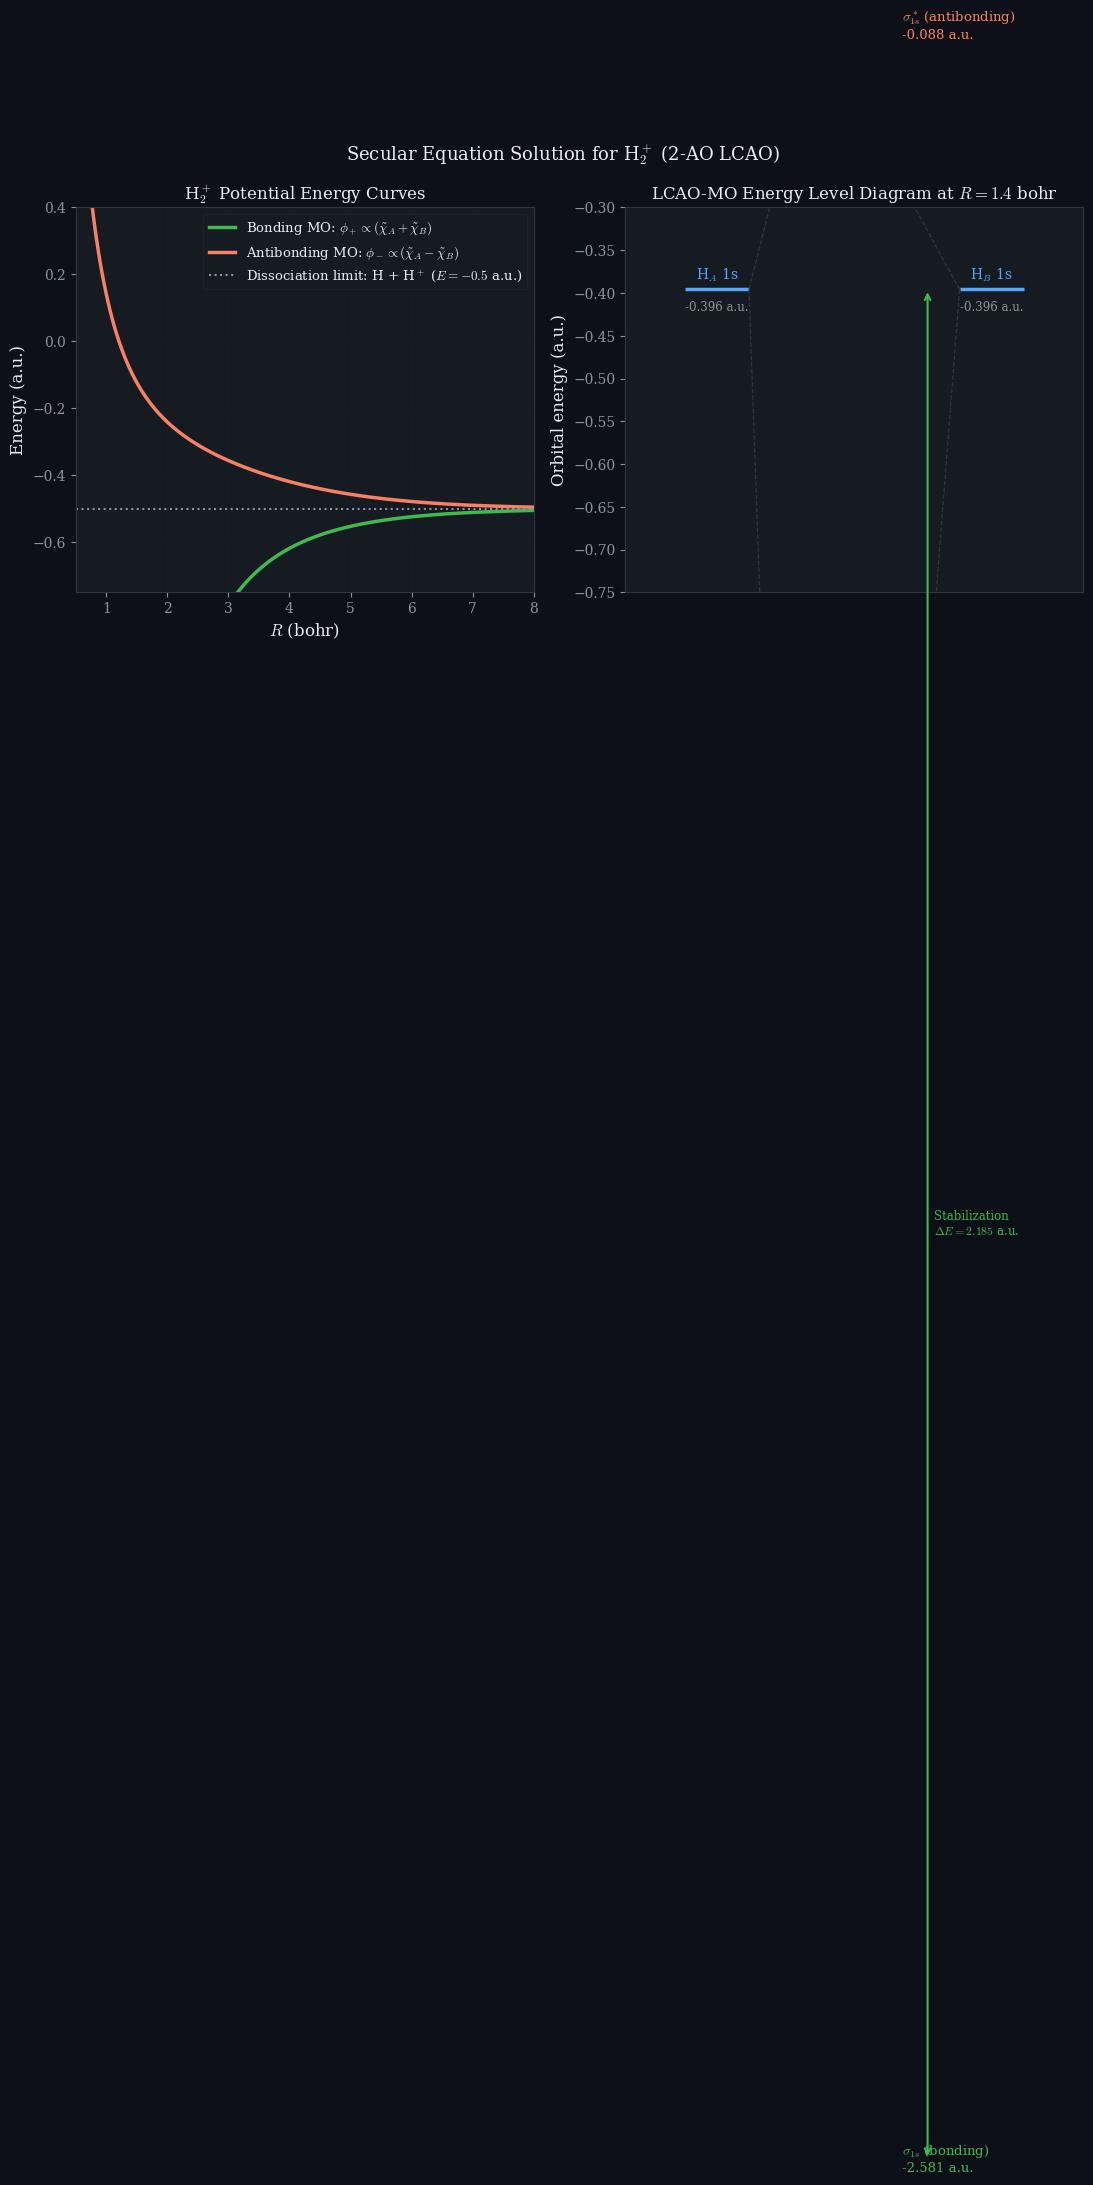

In [ ]:
# -----------------------------------------------------------------------
# H2+ potential energy curves from the 2-AO secular equation
# Matrix elements computed analytically for STO-1s basis
# Reference: Szabo & Ostlund, Modern Quantum Chemistry (1989), Ch. 1
# -----------------------------------------------------------------------
R_vals = np.linspace(0.5, 8.0, 400)
E_bond = np.zeros_like(R_vals)
E_anti = np.zeros_like(R_vals)
S_vals = np.zeros_like(R_vals)

for idx, R in enumerate(R_vals):
    S12  = np.exp(-R) * (1 + R + R**2/3.0)
    # H11 = T11 + V_AA + V_BA; with 1/R nuclear repulsion included
    H11  = -0.5 - (1.0/R) * (1.0 - np.exp(-2*R)*(1 + R)) + 1.0/R
    # H12 = S12 * (-0.5 + 1/R) + overlap correction
    H12  = S12 / R + np.exp(-R) * (-0.5*(1 + R))
    # Generalized eigenvalue problem: H*c = E*S*c
    H_mat = np.array([[H11, H12], [H12, H11]])
    S_mat = np.array([[1.0, S12], [S12, 1.0]])
    evals, _ = eigh(H_mat, S_mat)
    E_bond[idx] = evals[0]
    E_anti[idx] = evals[1]
    S_vals[idx] = S12

i_eq = np.argmin(E_bond)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: PES ---
ax = axes[0]
ax.plot(R_vals, E_bond, color='#3fb950', lw=2.5,
        label=r'Bonding MO: $\phi_+ \propto (\tilde{\chi}_A + \tilde{\chi}_B)$')
ax.plot(R_vals, E_anti, color='#f78166', lw=2.5,
        label=r'Antibonding MO: $\phi_- \propto (\tilde{\chi}_A - \tilde{\chi}_B)$')
ax.axhline(-0.5, color='#8b949e', ls=':', lw=1.5,
           label='Dissociation limit: H + H$^+$ ($E = -0.5$ a.u.)')
ax.scatter([R_vals[i_eq]], [E_bond[i_eq]], color='#3fb950', s=80, zorder=5)
ax.annotate(f'$R_e = {R_vals[i_eq]:.2f}$ bohr\n$E = {E_bond[i_eq]:.3f}$ a.u.',
            xy=(R_vals[i_eq], E_bond[i_eq]),
            xytext=(R_vals[i_eq] + 1.3, E_bond[i_eq] + 0.15),
            color='#3fb950', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#3fb950', lw=1))
ax.set_xlabel('$R$ (bohr)', fontsize=12)
ax.set_ylabel('Energy (a.u.)', fontsize=12)
ax.set_title(r'H$_2^+$ Potential Energy Curves', fontsize=12)
ax.legend(fontsize=9.5, framealpha=0.3)
ax.set_xlim(0.5, 8); ax.set_ylim(-0.75, 0.4)
ax.grid(alpha=0.2)

# --- Right: MO diagram ---
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(-0.75, -0.3)
ax2.set_ylabel('Orbital energy (a.u.)', fontsize=12)
ax2.set_title(r'LCAO-MO Energy Level Diagram at $R = 1.4$ bohr', fontsize=12)
ax2.set_xticks([])

R_d   = 1.4
S_d   = np.exp(-R_d)*(1 + R_d + R_d**2/3)
H11_d = -0.5 - (1.0/R_d)*(1 - np.exp(-2*R_d)*(1 + R_d)) + 1.0/R_d
H12_d = S_d/R_d + np.exp(-R_d)*(-0.5*(1 + R_d))
ev, _  = eigh(np.array([[H11_d, H12_d],[H12_d, H11_d]]),
              np.array([[1.0, S_d],[S_d, 1.0]]))

for x, lab in [(2.0, r'H$_A$ 1s'), (8.0, r'H$_B$ 1s')]:
    ax2.hlines(H11_d, x-0.7, x+0.7, colors='#58a6ff', lw=2.5)
    ax2.text(x, H11_d - 0.025, f'{H11_d:.3f} a.u.', ha='center',
             color='#8b949e', fontsize=8.5)
    ax2.text(x, H11_d + 0.012, lab, ha='center', color='#58a6ff', fontsize=10)

mo_info = [(5, ev[0], r'$\sigma_{1s}$ (bonding)', '#3fb950'),
           (5, ev[1], r'$\sigma^*_{1s}$ (antibonding)', '#f78166')]
for x, e, lab, col in mo_info:
    ax2.hlines(e, x-0.85, x+0.85, colors=col, lw=2.5)
    ax2.text(x + 1.05, e, f'{lab}\n{e:.3f} a.u.', va='center', color=col, fontsize=9.5)

# Mixing lines
for xa in [2.7, 7.3]:
    for xe, ye in [(4.15, ev[0]), (4.15, ev[1])]:
        ax2.plot([xa, xe], [H11_d, ye], color='#30363d', lw=0.9, ls='--')

# dE annotation
dE = H11_d - ev[0]
ax2.annotate('', xy=(6.6, H11_d), xytext=(6.6, ev[0]),
             arrowprops=dict(arrowstyle='<->', color='#3fb950', lw=1.5))
ax2.text(6.75, (H11_d + ev[0])/2,
         f'Stabilization\n$\\Delta E = {dE:.3f}$ a.u.',
         va='center', color='#3fb950', fontsize=8.5)
ax2.grid(alpha=0.15, axis='y')

plt.suptitle('Secular Equation Solution for H$_2^+$ (2-AO LCAO)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. The Hartree–Fock Energy Functional

We now extend the variational treatment to a full $N$-electron Slater determinant. The HF energy is the expectation value $E_{\text{HF}} = \mel{\Phi}{\hat{H}}{\Phi}$. Evaluating this with the one- and two-electron structure of $\hat{H}$ requires Slater's rules for matrix elements of a determinantal wavefunction.

### 5.1 Slater's Rules for Matrix Elements

For a normalized Slater determinant $\ket{\Phi}$ with orthonormal spin orbitals $\{\chi_i\}$, the expectation values of one- and two-electron operators are [4]:

$$\mel{\Phi}{\sum_i \hat{h}(i)}{\Phi} = \sum_{i=1}^{N}\mel{\chi_i}{\hat{h}}{\chi_i}$$

$$\mel{\Phi}{\sum_{i<j}\frac{1}{r_{ij}}}{\Phi} = \frac{1}{2}\sum_{i,j=1}^{N}\bigl(J_{ij} - K_{ij}\bigr)$$

where the **Coulomb integral** is:

$$J_{ij} = \int\!\int d\mathbf{x}_1\,d\mathbf{x}_2\;|\chi_i(\mathbf{x}_1)|^2\,\frac{1}{r_{12}}\,|\chi_j(\mathbf{x}_2)|^2$$

and the **exchange integral** is:

$$K_{ij} = \int\!\int d\mathbf{x}_1\,d\mathbf{x}_2\;\chi_i^*(\mathbf{x}_1)\chi_j^*(\mathbf{x}_2)\,\frac{1}{r_{12}}\,\chi_j(\mathbf{x}_1)\chi_i(\mathbf{x}_2)$$

Both integrals are real and non-negative. The total HF energy is therefore:

$$\boxed{E_{\text{HF}} = \sum_{i=1}^{N}\mel{i}{\hat{h}}{i} + \frac{1}{2}\sum_{i,j=1}^{N}\bigl(J_{ij} - K_{ij}\bigr) + V_{NN}}$$

### 5.2 Physical Interpretation of $J$ and $K$

**The Coulomb integral $J_{ij}$** is the classical electrostatic repulsion between the electron charge densities $\rho_i(\mathbf{r}) = |\chi_i(\mathbf{r})|^2$ and $\rho_j(\mathbf{r}) = |\chi_j(\mathbf{r})|^2$. It has a clear classical analog: two charge clouds of the same sign repel. $J_{ij} > 0$ always.

**The exchange integral $K_{ij}$** has no classical analog whatsoever. It arises solely from the antisymmetry of the Slater determinant—it would vanish for a Hartree product. Notice that $\chi_i$ and $\chi_j$ have *exchanged* positions in $K_{ij}$ relative to $J_{ij}$: the bra $\chi_i^*(\mathbf{x}_1)$ is paired with the ket $\chi_j(\mathbf{x}_1)$, not $\chi_i(\mathbf{x}_1)$. Since spin integration is embedded in $\chi^*(\mathbf{x})\chi(\mathbf{x})$, the spin parts must match: $K_{ij} = 0$ if $\chi_i$ and $\chi_j$ have opposite spin.

The physical consequence is the **Fermi hole**: same-spin electrons are statistically kept apart beyond what Coulomb repulsion alone demands, because antisymmetry forces the spatial wavefunction to vanish when two like-spin electrons coincide. Since $K_{ij}$ enters with a minus sign, aligning spins *lowers* the HF energy—this is Hund's first rule [4].

### 5.3 The Fock Operator

To minimize $E_{\text{HF}}$ over the spin orbitals subject to the orthonormality constraint $\braket{\chi_i}{\chi_j} = \delta_{ij}$, we introduce Lagrange multipliers $\varepsilon_{ij}$ and require $\delta L = 0$ where $L = E_{\text{HF}} - \sum_{ij}\varepsilon_{ij}(\braket{\chi_i}{\chi_j} - \delta_{ij})$. The resulting Euler–Lagrange equations are the **Hartree–Fock equations** [3,4]:

$$\hat{f}\,\chi_i(\mathbf{x}) = \varepsilon_i\,\chi_i(\mathbf{x})$$

where the **Fock operator** is:

$$\boxed{\hat{f}(\mathbf{x}_1) = \hat{h}(\mathbf{x}_1) + \sum_{j=1}^{N}\bigl[\hat{J}_j(\mathbf{x}_1) - \hat{K}_j(\mathbf{x}_1)\bigr]}$$

The **Coulomb operator** acts locally—it is an ordinary potential:

$$\hat{J}_j(\mathbf{x}_1)\,\chi_i(\mathbf{x}_1) = \left[\int d\mathbf{x}_2\;|\chi_j(\mathbf{x}_2)|^2\,\frac{1}{r_{12}}\right]\chi_i(\mathbf{x}_1)$$

The **exchange operator** acts non-locally—its value at $\mathbf{x}_1$ depends on $\chi_i$ at all other points:

$$\hat{K}_j(\mathbf{x}_1)\,\chi_i(\mathbf{x}_1) = \left[\int d\mathbf{x}_2\;\chi_j^*(\mathbf{x}_2)\,\frac{1}{r_{12}}\,\chi_i(\mathbf{x}_2)\right]\chi_j(\mathbf{x}_1)$$

Note that $[\hat{J}_j - \hat{K}_j]\chi_j = 0$ (the self-interaction cancels), so the sum over $j$ effectively excludes the orbital acted upon. The Fock operator describes each electron moving in the *average field* of all the others—this is what makes HF a mean-field theory.

> **Note on Diagonalization.** The Lagrange multipliers $\varepsilon_{ij}$ are initially a full matrix. A canonical transformation of the occupied orbitals (a unitary rotation that does not change the determinant or the energy) can always diagonalize this matrix, yielding $\varepsilon_{ij} = \varepsilon_i\delta_{ij}$—the canonical form. The canonical HF orbitals are thus eigenfunctions of $\hat{f}$ with real eigenvalues $\varepsilon_i$ [5].

---
## 6. The Roothaan–Hall Equations

The Hartree–Fock equation $\hat{f}\,\phi_i = \varepsilon_i\,\phi_i$ is an integro-differential equation in continuous function space. Its numerical solution requires discretization. Substituting the LCAO expansion $\phi_i = \sum_\nu C_{\nu i}\tilde{\chi}_\nu$ into the HF equation, and projecting from the left onto each basis function $\tilde{\chi}_\mu^*$:

$$\int d\mathbf{r}\;\tilde{\chi}_\mu^*(\mathbf{r})\,\hat{f}(\mathbf{r})\sum_\nu C_{\nu i}\tilde{\chi}_\nu(\mathbf{r}) = \varepsilon_i\int d\mathbf{r}\;\tilde{\chi}_\mu^*(\mathbf{r})\sum_\nu C_{\nu i}\tilde{\chi}_\nu(\mathbf{r})$$

Since $C_{\nu i}$ are constants, they factor out of the integrals:

$$\sum_\nu C_{\nu i}\int d\mathbf{r}\;\tilde{\chi}_\mu^*(\mathbf{r})\,\hat{f}\,\tilde{\chi}_\nu(\mathbf{r}) = \varepsilon_i\sum_\nu C_{\nu i}\int d\mathbf{r}\;\tilde{\chi}_\mu^*(\mathbf{r})\tilde{\chi}_\nu(\mathbf{r})$$

Defining $F_{\mu\nu} = \mel{\tilde{\chi}_\mu}{\hat{f}}{\tilde{\chi}_\nu}$ and $S_{\mu\nu} = \braket{\tilde{\chi}_\mu}{\tilde{\chi}_\nu}$, this is:

$$\sum_\nu F_{\mu\nu}\,C_{\nu i} = \varepsilon_i\sum_\nu S_{\mu\nu}\,C_{\nu i}$$

Written for all $\mu = 1, \ldots, K$ simultaneously, this is the **Roothaan–Hall equation** [6,7]:

$$\boxed{\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\,\boldsymbol{\varepsilon}}$$

This is a $K\times K$ **generalized matrix eigenvalue equation**. When $\mathbf{S} = \mathbf{I}$ (orthonormal basis), it reduces to a standard eigenvalue problem. Since atomic orbital bases are never orthonormal across atoms, solving it requires a preliminary orthogonalization step.

### 6.1 The Fock Matrix in the AO Basis

Expanding the Fock operator $\hat{f} = \hat{h} + \hat{J} - \hat{K}$ in the AO basis yields the Fock matrix elements [5]:

$$F_{\mu\nu} = h_{\mu\nu} + \sum_{\lambda=1}^{K}\sum_{\sigma=1}^{K} P_{\lambda\sigma}\left[(\mu\nu|\lambda\sigma) - \frac{1}{2}(\mu\sigma|\lambda\nu)\right]$$

where the **core Hamiltonian matrix** $h_{\mu\nu} = \mel{\tilde{\chi}_\mu}{\hat{h}}{\tilde{\chi}_\nu}$ contains kinetic energy and nuclear attraction integrals, and the **electron repulsion integrals (ERIs)** are:

$$(\mu\nu|\lambda\sigma) = \int\!\int d\mathbf{r}_1\,d\mathbf{r}_2\; \tilde{\chi}_\mu(\mathbf{r}_1)\tilde{\chi}_\nu(\mathbf{r}_1)\,\frac{1}{r_{12}}\,\tilde{\chi}_\lambda(\mathbf{r}_2)\tilde{\chi}_\sigma(\mathbf{r}_2)$$

The first ERI term, $(\mu\nu|\lambda\sigma)$, builds the Coulomb contribution (electron in $\mu$–$\nu$ repels electron in $\lambda$–$\sigma$). The second, $(\mu\sigma|\lambda\nu)$, builds the exchange contribution, with indices $\nu$ and $\sigma$ transposed.

### 6.2 The Density Matrix

The **density matrix** $\mathbf{P}$ links the MO coefficients to the observable electron density. For a closed-shell system with $N/2$ doubly-occupied spatial orbitals:

$$P_{\mu\nu} = 2\sum_{i=1}^{N/2} C_{\mu i}\,C_{\nu i}^*$$

The factor of 2 accounts for two electrons (one $\alpha$, one $\beta$) in each spatial orbital. In terms of the density matrix, the electron number is $N = \text{Tr}[\mathbf{P}\mathbf{S}]$, and the electron density at point $\mathbf{r}$ is:

$$\rho(\mathbf{r}) = \sum_{\mu\nu} P_{\mu\nu}\,\tilde{\chi}_\mu(\mathbf{r})\,\tilde{\chi}_\nu(\mathbf{r})$$

This is the AO-basis representation of the electron density. The density matrix appears in the Fock matrix through $P_{\lambda\sigma}$, making $\mathbf{F}$ explicitly dependent on its own solution $\mathbf{C}$.

### 6.3 The Total HF Energy in AO Notation

Using $\mathbf{P}$ and $\mathbf{F}$, the total HF energy can be written compactly [5]:

$$E_{\text{HF}} = \frac{1}{2}\,\text{Tr}[\mathbf{P}(\mathbf{h} + \mathbf{F})] + V_{NN}$$

The $1/2$ factor avoids double-counting: the two-electron repulsion is already built into both $\mathbf{P}$ (via the occupied orbitals) and $\mathbf{F}$ (via the mean field). Including $\mathbf{h}$ in the trace along with $\mathbf{F}$ combines kinetic energy, nuclear attraction, and electron repulsion in one expression.

### 6.4 Koopmans' Theorem

The orbital energies $\varepsilon_i$ have a direct physical interpretation. **Koopmans' theorem** [9] states that the ionization potential of removing an electron from orbital $i$ is approximately $-\varepsilon_i$:

$$\text{IP}_i \approx -\varepsilon_i$$

The derivation assumes **frozen orbitals**: after ionization, the remaining electrons occupy the same orbitals as in the neutral molecule (no relaxation). Under this assumption, $E(N-1\text{ electrons}) - E(N\text{ electrons}) = -\varepsilon_i$ exactly. In practice, orbital relaxation lowers the ionization energy by typically 1–2%, making Koopmans' predictions qualitatively—but not quantitatively—correct.

---
## 7. The Self-Consistent Field Procedure

### 7.1 The Self-Consistency Problem

The central complication of the Roothaan–Hall equation is that $\mathbf{F}$ depends on $\mathbf{P}$, which depends on $\mathbf{C}$—the solution we seek. This is a **nonlinear eigenvalue problem**: the operator whose eigenvectors we want depends on those eigenvectors themselves. We cannot simply diagonalize $\mathbf{F}$ once; we must iterate until the input and output density matrices agree to within a chosen tolerance.

### 7.2 Löwdin Orthogonalization

Before diagonalizing, the generalized eigenvalue problem $\mathbf{FC} = \mathbf{SC}\boldsymbol{\varepsilon}$ must be transformed into a standard one. The Löwdin symmetric orthogonalization [8] achieves this by constructing the **orthogonalizer** $\mathbf{X}$.

Diagonalize the overlap matrix: $\mathbf{S} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^\dagger$ (eigenvectors $\mathbf{V}$, eigenvalues $\boldsymbol{\Lambda}$). Then:

$$\mathbf{X} = \mathbf{V}\boldsymbol{\Lambda}^{-1/2}\mathbf{V}^\dagger, \qquad \text{such that } \mathbf{X}^\dagger\mathbf{S}\mathbf{X} = \mathbf{I}$$

Substituting $\mathbf{C} = \mathbf{X}\tilde{\mathbf{C}}$ into $\mathbf{FC} = \mathbf{SC}\boldsymbol{\varepsilon}$ and multiplying from the left by $\mathbf{X}^\dagger$:

$$\underbrace{\mathbf{X}^\dagger\mathbf{F}\mathbf{X}}_{\mathbf{F}'}\tilde{\mathbf{C}} = \tilde{\mathbf{C}}\,\boldsymbol{\varepsilon}$$

This is now a standard $K\times K$ eigenvalue problem, solvable by any dense eigensolver. The physical MO coefficients are recovered via $\mathbf{C} = \mathbf{X}\tilde{\mathbf{C}}$.

### 7.3 The SCF Algorithm

The complete iterative procedure is:

1. **Setup:** Choose basis $\{\tilde{\chi}_\mu\}$; compute one-time integrals $\mathbf{S}$, $\mathbf{h}$, and all $K^4/8$ ERIs $(\mu\nu|\lambda\sigma)$.
2. **Orthogonalizer:** Diagonalize $\mathbf{S}$; form $\mathbf{X} = \mathbf{V}\boldsymbol{\Lambda}^{-1/2}\mathbf{V}^\dagger$.
3. **Initial guess:** Choose $\mathbf{P}^{(0)}$ (e.g., $\mathbf{P}^{(0)} = \mathbf{0}$, the core Hamiltonian guess, or a superposition of atomic densities).
4. **SCF iteration** (repeat until converged):
   - Build $F_{\mu\nu} = h_{\mu\nu} + \sum_{\lambda\sigma}P_{\lambda\sigma}[(\mu\nu|\lambda\sigma) - \frac{1}{2}(\mu\sigma|\lambda\nu)]$
   - Transform: $\mathbf{F}' = \mathbf{X}^\dagger\mathbf{F}\mathbf{X}$
   - Diagonalize: $\mathbf{F}'\tilde{\mathbf{C}} = \tilde{\mathbf{C}}\,\boldsymbol{\varepsilon}$ (sort by ascending $\varepsilon_i$)
   - Back-transform: $\mathbf{C} = \mathbf{X}\tilde{\mathbf{C}}$
   - Update density: $P_{\mu\nu} = 2\sum_{i=1}^{N/2}C_{\mu i}C_{\nu i}^*$
   - Compute energy: $E = \frac{1}{2}\text{Tr}[\mathbf{P}(\mathbf{h}+\mathbf{F})] + V_{NN}$
   - **Convergence check:** $|\Delta E| < \delta_E$ **and** $\|\mathbf{P}^{\text{new}} - \mathbf{P}^{\text{old}}\|_{\text{rms}} < \delta_P$
5. **Output:** Converged $\mathbf{C}$, $\boldsymbol{\varepsilon}$, $E_{\text{HF}}$.

Typical convergence thresholds are $\delta_E = 10^{-8}$ Ha and $\delta_P = 10^{-6}$. The number of SCF cycles required depends strongly on the initial guess and the choice of convergence acceleration (DIIS, damping, level shifting).

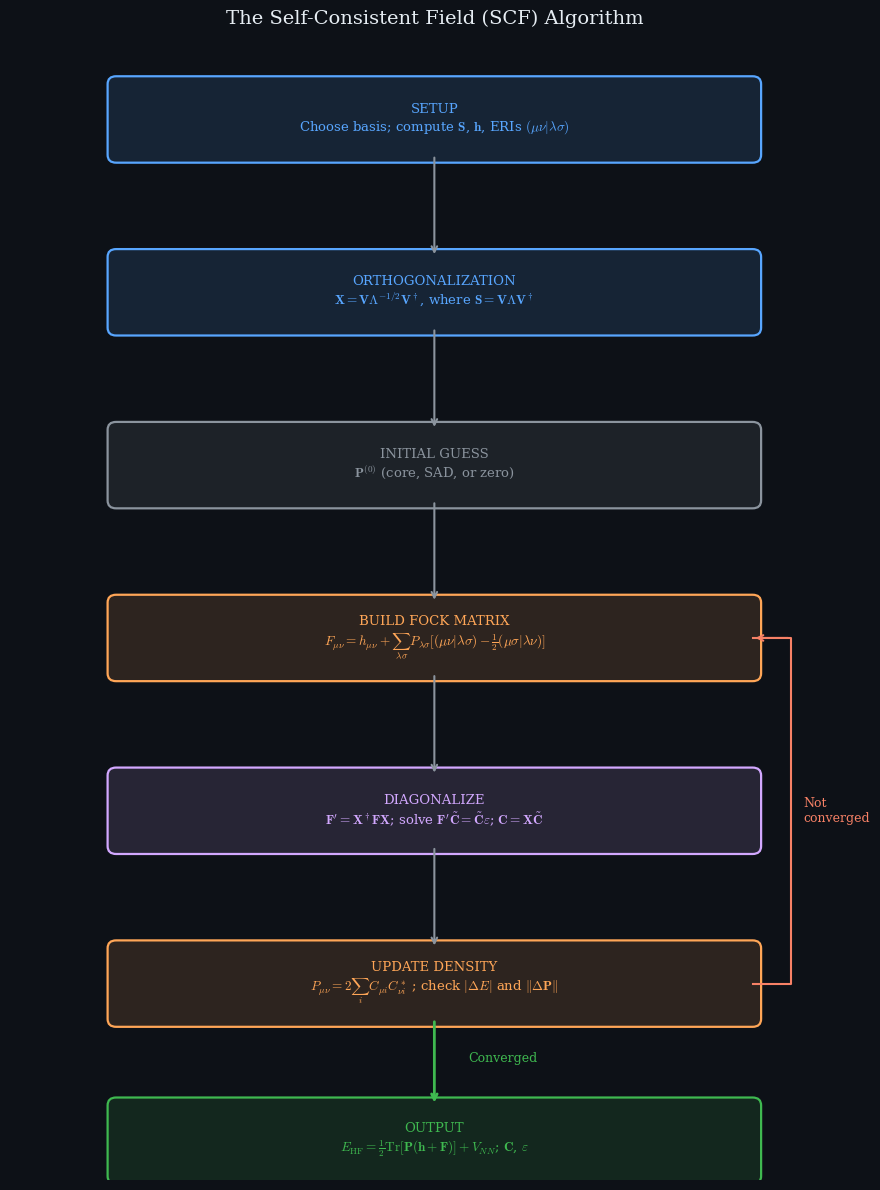

In [ ]:
# -----------------------------------------------------------------------
# SCF algorithm flowchart
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 12))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 14)
ax.axis('off')
ax.set_title('The Self-Consistent Field (SCF) Algorithm', fontsize=14, pad=12)

steps = [
    (5, 13.0, 'SETUP\nChoose basis; compute $\\mathbf{S}$, $\\mathbf{h}$, ERIs $(\\mu\\nu|\\lambda\\sigma)$',     '#58a6ff'),
    (5, 10.8, 'ORTHOGONALIZATION\n$\\mathbf{X} = \\mathbf{V}\\boldsymbol{\\Lambda}^{-1/2}\\mathbf{V}^\\dagger$, where $\\mathbf{S} = \\mathbf{V}\\boldsymbol{\\Lambda}\\mathbf{V}^\\dagger$', '#58a6ff'),
    (5,  8.6, 'INITIAL GUESS\n$\\mathbf{P}^{(0)}$ (core, SAD, or zero)', '#8b949e'),
    (5,  6.4, 'BUILD FOCK MATRIX\n$F_{\\mu\\nu} = h_{\\mu\\nu} + \\sum_{\\lambda\\sigma}P_{\\lambda\\sigma}[(\\mu\\nu|\\lambda\\sigma) - \\frac{1}{2}(\\mu\\sigma|\\lambda\\nu)]$', '#ffa657'),
    (5,  4.2, 'DIAGONALIZE\n$\\mathbf{F}^{\\prime} = \\mathbf{X}^\\dagger\\mathbf{F}\\mathbf{X}$; solve $\\mathbf{F}^{\\prime}\\tilde{\\mathbf{C}} = \\tilde{\\mathbf{C}}\\boldsymbol{\\varepsilon}$; $\\mathbf{C} = \\mathbf{X}\\tilde{\\mathbf{C}}$', '#d2a8ff'),
    (5,  2.0, 'UPDATE DENSITY\n$P_{\\mu\\nu} = 2\\sum_i C_{\\mu i}C_{\\nu i}^*$ ; check $|\\Delta E|$ and $\\|\\Delta\\mathbf{P}\\|$', '#ffa657'),
    (5,  0.0, 'OUTPUT\n$E_{\\text{HF}} = \\frac{1}{2}\\text{Tr}[\\mathbf{P}(\\mathbf{h}+\\mathbf{F})] + V_{NN}$; $\\mathbf{C}$, $\\boldsymbol{\\varepsilon}$', '#3fb950'),
]

bw, bh = 7.5, 0.90

for cx, cy, label, col in steps:
    rect = mpatches.FancyBboxPatch((cx - bw/2, cy - bh/2), bw, bh,
                                    boxstyle='round,pad=0.1',
                                    facecolor=col + '22', edgecolor=col, lw=1.6)
    ax.add_patch(rect)
    ax.text(cx, cy, label, ha='center', va='center', fontsize=9.5, color=col)

# Sequential down-arrows
for i in range(len(steps) - 2):
    cy_top = steps[i][1]
    cy_bot = steps[i+1][1]
    ax.annotate('', xy=(5, cy_bot + bh/2), xytext=(5, cy_top - bh/2),
                arrowprops=dict(arrowstyle='->', color='#8b949e', lw=1.5))

# Converged arrow
cy_update = steps[-2][1]; cy_out = steps[-1][1]
ax.annotate('', xy=(5, cy_out + bh/2), xytext=(5, cy_update - bh/2),
            arrowprops=dict(arrowstyle='->', color='#3fb950', lw=2.0))
ax.text(5.4, (cy_update + cy_out)/2, 'Converged', color='#3fb950', fontsize=9)

# Loop-back arrow (not converged)
cy_fock = steps[3][1]
ax.plot([5 + bw/2, 9.2, 9.2, 5 + bw/2],
        [cy_update, cy_update, cy_fock, cy_fock],
        color='#f78166', lw=1.5)
ax.annotate('', xy=(5 + bw/2, cy_fock), xytext=(9.2, cy_fock),
            arrowprops=dict(arrowstyle='->', color='#f78166', lw=1.5))
ax.text(9.35, (cy_update + cy_fock)/2,
        'Not\nconverged', color='#f78166', fontsize=9, va='center')

plt.tight_layout()
plt.show()

---
## 8. Convergence, Computational Scaling, and Practical Limits

### 8.1 SCF Convergence

Naïve SCF iteration (Roothaan's original procedure) does not always converge. When the HOMO–LUMO gap is small—as in transition metal complexes or near-degenerate states—the density matrix oscillates between iterations rather than converging. Two standard remedies:

**Damping:** replace $\mathbf{P}^{\text{new}}$ with a linear mix $(1-\lambda)\mathbf{P}^{\text{old}} + \lambda\mathbf{P}^{\text{new}}$ for some $0 < \lambda < 1$. Damping slows convergence but damps oscillations.

**DIIS (Direct Inversion in the Iterative Subspace) [10]:** extrapolate the next Fock matrix from a linear combination of the last $m$ Fock matrices $\{\mathbf{F}^{(k)}\}$, weighted to minimize the error vector $\mathbf{e}^{(k)} = \mathbf{F}^{(k)}\mathbf{P}^{(k)}\mathbf{S} - \mathbf{S}\mathbf{P}^{(k)}\mathbf{F}^{(k)}$ (which measures how far the current orbitals are from satisfying $[\mathbf{F},\mathbf{P}] = \mathbf{0}$). DIIS typically converges in 10–20 iterations and is the default in every major quantum chemistry package.

### 8.2 Computational Scaling

The dominant cost of a conventional HF calculation is the two-electron integral computation and transformation. The number of symmetry-unique ERIs scales as $\mathcal{O}(K^4/8)$. For a molecule with $n$ atoms and a split-valence basis, $K \sim 10n$, giving $\sim 10^4 n^4/8$ integrals. For $n = 10$ (small organic), this is $\sim 10^5$ integrals—trivial. For $n = 100$, it is $\sim 10^9$—demanding. For $n = 1000$, it is $\sim 10^{13}$—prohibitive with exact integrals.

Modern implementations circumvent this with density fitting (DF-HF), linear-scaling algorithms, and integral screening (neglecting integrals below a threshold). In practice, HF scales closer to $\mathcal{O}(K^{2\text{–}3})$ for large systems with screening.

### 8.3 Basis Set Truncation Error

Even with perfect SCF convergence, the LCAO result is only as good as the basis. The **basis set superposition error (BSSE)** is an artefact in interaction energy calculations: the basis functions of molecule $A$ artificially stabilize molecule $B$ by providing additional variational flexibility. It is corrected by the counterpoise method. The **basis set incompleteness error (BSIE)** is the difference between the energy in a finite basis and the HF limit; it decreases monotonically as the basis is enlarged toward completeness.

---
## 9. Beyond Hartree–Fock: The Correlation Problem

Even in the complete basis set limit, Hartree–Fock is not exact. The single-determinant ansatz cannot capture **electron correlation**—the correlated motion of electrons beyond what the average mean field encodes.

### 9.1 The Correlation Energy

The **correlation energy** is defined as:

$$E_c = E_0 - E_{\text{HF}} < 0$$

By the variational principle, $E_c < 0$ always. For most molecules, $|E_c|/|E_{\text{HF}}|$ is small ($\lesssim 1\%$), but it is comparable to bond dissociation energies (typically $1$–$5$ eV). Accurate thermochemistry therefore requires recovering $E_c$.

**Static correlation** arises when two or more determinants contribute nearly equally to the ground state—near bond-breaking, in biradicals, or in transition states. HF fails qualitatively in these cases; the single-determinant approximation is fundamentally inadequate.

**Dynamic correlation** arises from instantaneous avoidance of electrons, even in systems well-described by a single determinant at equilibrium. It is recovered by multi-reference methods (CASSCF, CASPT2) for static correlation, and by perturbation theory (MP2), coupled cluster (CCSD, CCSD(T)), or configuration interaction (CISD) for dynamic correlation.

### 9.2 Post-HF Methods: Hierarchy

The post-HF methods all retain the LCAO framework; they differ in the many-electron wavefunction beyond the single determinant.

| Method | Wavefunction Ansatz | Scaling | Accuracy |
|:-------|:--------------------|:--------|:---------|
| HF | Single determinant | $\mathcal{O}(K^4)$ | No correlation |
| MP2 | HF + 2nd-order perturbation | $\mathcal{O}(K^5)$ | ~80% of $E_c$ |
| CCSD | HF + singles + doubles CC | $\mathcal{O}(K^6)$ | ~95% of $E_c$ |
| CCSD(T) | CCSD + perturbative triples | $\mathcal{O}(K^7)$ | "Gold standard" |
| FCI | All determinants | $\mathcal{O}(K!)$ | Exact in basis |

Hartree–Fock thus occupies the base of a systematic hierarchy. Its value is not that it gives exact energies, but that it provides the optimal single-determinant reference from which all higher-level corrections are built.

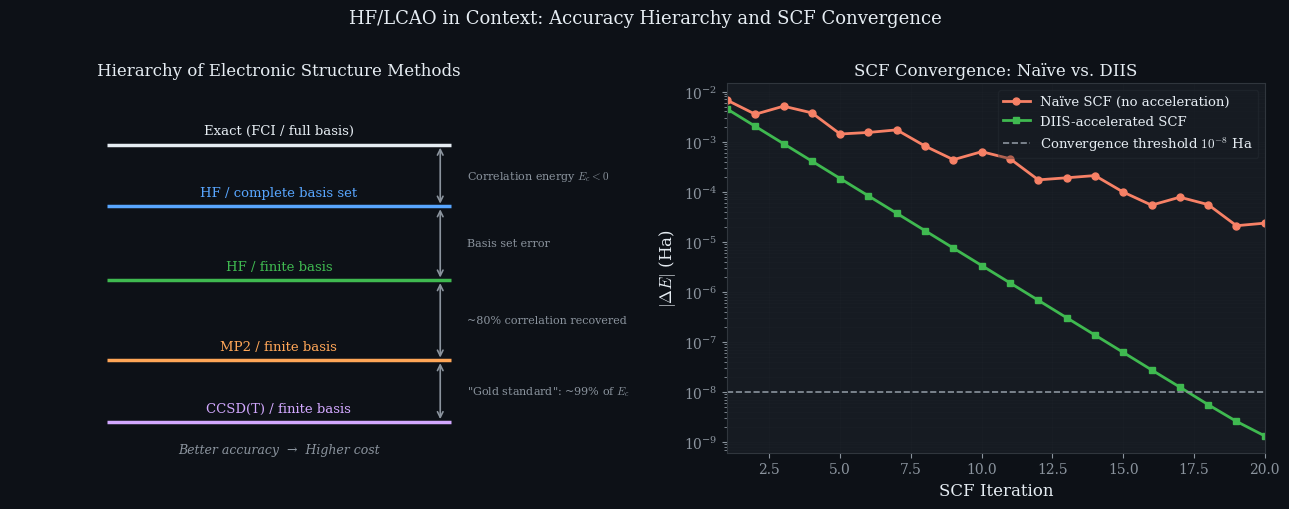

In [ ]:
# -----------------------------------------------------------------------
# Summary: HF energy hierarchy and the basis set / correlation cube
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: energy hierarchy schematic ---
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(-5, 1)
ax.axis('off')
ax.set_title('Hierarchy of Electronic Structure Methods', fontsize=12)

levels = [
    (5, 0.0,  'Exact (FCI / full basis)', '#e6edf3', ''),
    (5, -1.0, 'HF / complete basis set', '#58a6ff', 'Correlation energy $E_c < 0$'),
    (5, -2.2, 'HF / finite basis', '#3fb950', 'Basis set error'),
    (5, -3.5, 'MP2 / finite basis', '#ffa657', '~80% correlation recovered'),
    (5, -4.5, 'CCSD(T) / finite basis', '#d2a8ff', '"Gold standard": ~99% of $E_c$'),
]

for x, y, lab, col, sub in levels:
    ax.hlines(y, x-3.2, x+3.2, colors=col, lw=2.5)
    ax.text(x, y + 0.17, lab, ha='center', color=col, fontsize=9.5)
    if sub:
        ax.annotate('', xy=(x+3.0, y), xytext=(x+3.0, levels[levels.index((x,y,lab,col,sub))-1][1]),
                    arrowprops=dict(arrowstyle='<->', color='#8b949e', lw=1.2))
        prev_y = levels[levels.index((x,y,lab,col,sub))-1][1]
        ax.text(x+3.5, (y + prev_y)/2, sub, va='center', color='#8b949e', fontsize=8)

ax.text(5, -5.0, 'Better accuracy  →  Higher cost', ha='center',
        color='#8b949e', fontsize=9, style='italic')

# --- Right: SCF convergence simulation ---
ax2 = axes[1]
# Simulate a typical SCF convergence: exponential decay with oscillations
np.random.seed(42)
n_iter = 20
iters  = np.arange(1, n_iter+1)
# DIIS-like fast convergence
dE_diis  = 1e-2 * np.exp(-0.8 * iters) + 1e-10 * np.random.randn(n_iter)**2
# Naïve SCF with oscillations, slower convergence
dE_naive = 1e-2 * np.exp(-0.3 * iters) * (1 + 0.4*np.cos(1.8*iters)) + 1e-9
dE_diis  = np.abs(dE_diis)  + 1e-12
dE_naive = np.abs(dE_naive) + 1e-12

ax2.semilogy(iters, dE_naive, color='#f78166', lw=2, marker='o', markersize=5, label='Naïve SCF (no acceleration)')
ax2.semilogy(iters, dE_diis,  color='#3fb950', lw=2, marker='s', markersize=5, label='DIIS-accelerated SCF')
ax2.axhline(1e-8, color='#8b949e', ls='--', lw=1.2, label='Convergence threshold $10^{-8}$ Ha')
ax2.set_xlabel('SCF Iteration', fontsize=12)
ax2.set_ylabel('$|\\Delta E|$ (Ha)', fontsize=12)
ax2.set_title('SCF Convergence: Naïve vs. DIIS', fontsize=12)
ax2.legend(fontsize=9.5, framealpha=0.3)
ax2.grid(alpha=0.25, which='both')
ax2.set_xlim(1, n_iter)

plt.suptitle('HF/LCAO in Context: Accuracy Hierarchy and SCF Convergence', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

The LCAO method, combined with Hartree–Fock theory, provides a complete, self-contained framework for computing molecular electronic structure from first principles. Every step follows from two physical premises—the Born–Oppenheimer separation and the fermionic nature of electrons—and one mathematical tool—the variational principle. The logical chain is:

| Step | Concept | Physical/Mathematical Content |
|:----:|:-------:|:------------------------------|
| 1 | Born–Oppenheimer | Freeze nuclei; reduce to electronic $\hat{H}$ |
| 2 | LCAO ansatz | Expand MOs as $\phi_i = \sum_\mu C_{\mu i}\tilde{\chi}_\mu$; introduce $K^4$ ERIs |
| 3 | Slater determinant | Antisymmetric $N$-electron trial wavefunction; Pauli exclusion as a theorem |
| 4 | Variational principle | Minimize energy over $C_{\mu i}$; $E_{\text{var}} \geq E_0$ guarantees systematic improvability |
| 5 | Fock operator | Mean-field Hamiltonian: $\hat{f} = \hat{h} + \hat{J} - \hat{K}$; exchange is non-local |
| 6 | Density matrix | $P_{\mu\nu} = 2\sum_i C_{\mu i}C_{\nu i}^*$; links coefficients to observable density |
| 7 | Roothaan–Hall | $\mathbf{FC} = \mathbf{SC}\boldsymbol{\varepsilon}$: LCAO secular equation; nonlinear in $\mathbf{C}$ |
| 8 | SCF iteration | Solve iteratively via Löwdin orthogonalization + diagonalization + DIIS |

The Roothaan–Hall equation is simultaneously the culmination of the LCAO formalism and the starting point of virtually all electronic structure calculations. The second notebook implements this algorithm numerically and benchmarks it against PySCF.


---
## References

[1] Slater, J. C. The Theory of Complex Spectra. *Physical Review* **1929**, *34*(10), 1293–1322. https://doi.org/10.1103/PhysRev.34.1293

[2] Sherrill, C. D. An Introduction to Hartree-Fock Molecular Orbital Theory. School of Chemistry and Biochemistry, Georgia Institute of Technology, June 2000.

[3] Littlejohn, R. G. Notes 32: The Hartree-Fock Method in Atoms. *Physics 221B*, University of California, Berkeley, Academic Year 2021–22.

[4] Lehtola, S.; Blockhuys, F.; Van Alsenoy, C. An Overview of Self-Consistent Field Calculations Within Finite Basis Sets. *Molecules* **2020**, *25*(5), 1218. https://doi.org/10.3390/molecules25051218

[5] Roothaan, C. C. J. New Developments in Molecular Orbital Theory. *Reviews of Modern Physics* **1951**, *23*(2), 69–89. https://doi.org/10.1103/RevModPhys.23.69

[6] Hall, G. G. The Molecular Orbital Theory of Chemical Valency. VIII. A Method of Calculating Ionization Potentials. *Proceedings of the Royal Society A* **1951**, *205*(1083), 541–552. https://doi.org/10.1098/rspa.1951.0048

[7] Löwdin, P.-O. On the Nonorthogonality Problem. *Advances in Quantum Chemistry* **1970**, *5*, 185–199. https://doi.org/10.1016/S0065-3276(08)60339-1

[8] Pulay, P. Convergence Acceleration of Iterative Sequences. The Case of SCF Iteration. *Chemical Physics Letters* **1980**, *73*(2), 393–398. https://doi.org/10.1016/0009-2614(80)80396-4

[9] Szabo, A.; Ostlund, N. S. *Modern Quantum Chemistry: Introduction to Advanced Electronic Structure Theory*. Dover Publications, 1989. ISBN 978-0-486-69186-2.

[10] Hehre, W. J.; Stewart, R. F.; Pople, J. A. Self-Consistent Molecular-Orbital Methods. I. Use of Gaussian Expansions of Slater-Type Atomic Orbitals. *The Journal of Chemical Physics* **1969**, *51*(6), 2657–2664. https://doi.org/10.1063/1.1672392